In [14]:
import os
import random
import subprocess
import glob
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm
from PIL import Image

def get_random_crop_coords(img_h, img_w, crop_h, crop_w):
    """Generate random (x, y) coordinates for cropping."""
    if img_h <= crop_h or img_w <= crop_w:
        return 0, 0
    h_start = random.randint(0, img_h - crop_h)
    w_start = random.randint(0, img_w - crop_w)
    return h_start, w_start

def process_sequence(seq_path, out_dir_hr, out_dir_mr, out_dir_lr, crop_size, num_crops, scale_factor):
    """
    Crops a sequence multiple times and compresses it via FFmpeg with a downscale factor for LR.
    """
    frames = sorted(glob.glob(os.path.join(seq_path, "*.png")))
    if not frames:
        return

    # Read first frame to determine dimensions using Pillow
    with Image.open(frames[0]) as img:
        img_w, img_h = img.size
        
    crop_w, crop_h = crop_size

    for crop_idx in range(num_crops):
        # 1. Get identical crop coordinates for the entire sequence
        h_start, w_start = get_random_crop_coords(img_h, img_w, crop_h, crop_w)
        
        # Keep original subfolder structure (e.g. 00001/0001) and add crop index
        seq_parts = Path(seq_path).parts[-2:]
        crop_folder = os.path.join(*seq_parts, f"{crop_idx}")
        
        hr_crop_dir = os.path.join(out_dir_hr, crop_folder)
        mr_crop_dir = os.path.join(out_dir_mr, crop_folder)
        lr_crop_dir = os.path.join(out_dir_lr, crop_folder)
        os.makedirs(hr_crop_dir, exist_ok=True)
        os.makedirs(mr_crop_dir, exist_ok=True)
        os.makedirs(lr_crop_dir, exist_ok=True)
        
        # 2. Crop all frames and save to HR / MR target directory
        for i, f_path in enumerate(frames):
            with Image.open(f_path) as frame_img:
                # PIL uses (left, upper, right, lower)
                cropped = frame_img.crop((w_start, h_start, w_start + crop_w, h_start + crop_h))
                cropped.save(os.path.join(hr_crop_dir, f"im{i+1}.png"))

                cropped = cropped.resize((crop_w // scale_factor, crop_h // scale_factor), Image.BICUBIC)
                cropped.save(os.path.join(mr_crop_dir, f"im{i+1}.png"))
        
        # 3. Choose a random bitrate from 4 predefined options
        bitrate_options = [128, 256, 512, 1024]  # in kbps
        selected_bitrate = random.choice(bitrate_options)
        avg_bitrate = f"{selected_bitrate}k"
        max_bitrate = f"{selected_bitrate*2}k"
        bufsize = f"{selected_bitrate*2}k"
        temp_vid = os.path.join(lr_crop_dir, "temp.mp4")
        
        # 4. ffmpeg encode: HR frames -> H264 video with scaling for LR
        encode_cmd = [
            "ffmpeg", "-y", "-loglevel", "error",
            "-framerate", "30",
            "-i", os.path.join(hr_crop_dir, "im%d.png"),
            "-vf", f"scale=iw/{scale_factor}:ih/{scale_factor}",
            "-vcodec", "libx264",
            '-b:v', f'{avg_bitrate}', '-maxrate', f'{max_bitrate}', '-bufsize', f'{bufsize}',
            '-g', '14', '-keyint_min', '14', '-sc_threshold', '0', '-bf', '0', '-pix_fmt', 'yuv420p',
            temp_vid
        ]
        subprocess.run(encode_cmd, check=True)
        
        # 5. ffmpeg decode: H264 video -> LR Input frames
        decode_cmd = [
            "ffmpeg", "-y", "-loglevel", "error",
            "-i", temp_vid,
            os.path.join(lr_crop_dir, "im%d.png")
        ]
        subprocess.run(decode_cmd, check=True)
        
        # Clean up temporary video
        if os.path.exists(temp_vid):
            os.remove(temp_vid)

def run_preprocessing(dataset_root, output_dir, txt_file, crop_size=(256, 256), num_crops=3, scale_factor=4, num_workers=4):
    """
    Orchestrates the preprocessing over the entire dataset list.
    """
    list_path = os.path.join(dataset_root, txt_file)
    with open(list_path, 'r') as f:
        rel_paths = [line.strip() for line in f if line.strip()]

    out_hr = os.path.join(output_dir, "HR")
    out_mr = os.path.join(output_dir, "MR")
    out_lr = os.path.join(output_dir, "LR")
    os.makedirs(out_hr, exist_ok=True)
    os.makedirs(out_mr, exist_ok=True)
    os.makedirs(out_lr, exist_ok=True)

    seq_paths = [os.path.join(dataset_root, "sequences", p) for p in rel_paths]

    print(f"Starting processing for {len(seq_paths)} sequences from {txt_file}...")
    
    # Process sequences in parallel for speed
    with ThreadPoolExecutor(max_workers=num_workers) as executor:
        futures = []
        for seq_path in seq_paths:
            futures.append(
                executor.submit(process_sequence, seq_path, out_hr, out_mr, out_lr, crop_size, num_crops, scale_factor)
            )
        
        for _ in tqdm(futures, total=len(futures)):
            _.result()  # Wait for completion and catch exceptions
            
    print("Completed!")



In [15]:
# --- Configuration & Execution ---
VIMEO_DIR = "/mnt/d/datasets/visual/vimeo90k/"
OUTPUT_DIR = "/mnt/c/users/henrik/Downloads/vimeo90k_upscale/"

In [13]:
run_preprocessing(
    VIMEO_DIR,
    OUTPUT_DIR,
    "process_test.txt",
    crop_size=(256, 256),
    num_crops=1,
    scale_factor=2,
    num_workers=12
)

Starting processing for 25 sequences from process_test.txt...


100%|██████████| 25/25 [00:01<00:00, 13.08it/s]

Completed!


In [16]:
run_preprocessing(
    VIMEO_DIR,
    OUTPUT_DIR,
    "train.txt",
    crop_size=(256, 256),
    num_crops=1,
    scale_factor=2,
    num_workers=12
)

Starting processing for 64612 sequences from train.txt...


100%|██████████| 64612/64612 [1:40:36<00:00, 10.70it/s]  

Completed!


In [17]:
run_preprocessing(
    VIMEO_DIR,
    OUTPUT_DIR,
    "test.txt", 
    crop_size=(256, 256),
    num_crops=1,
    scale_factor=2,
    num_workers=12
)

Starting processing for 7824 sequences from test.txt...


  6%|▌         | 431/7824 [00:44<14:43,  8.37it/s]

100%|██████████| 7824/7824 [13:17<00:00,  9.81it/s]

Completed!


In [11]:
os.listdir(VIMEO_DIR)

['sequences', 'readme.txt', 'sep_testlist.txt', 'sep_trainlist.txt']

In [6]:
img = Image.open("/mnt/d/datasets/visual/vimeo90k/vimeo_septuplet/sequences/00001/0001/im1.png")
img.save("/mnt/d/upscale/test.png")

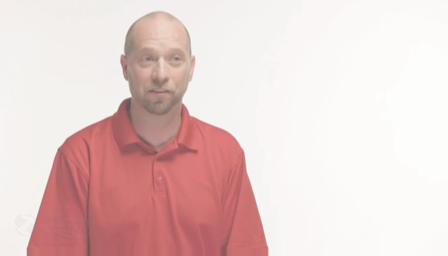

In [7]:
img